In [46]:
import sys, os
sys.path.append(os.path.abspath(".."))
from models import gemini_llm
from langchain.prompts import ChatPromptTemplate
from langgraph.graph import StateGraph, START, END, add_messages
from IPython.display import display, Image
from typing import TypedDict, Annotated
from langgraph.checkpoint.memory import MemorySaver
from langchain_core.output_parsers import JsonOutputParser

### Parallel design pattern

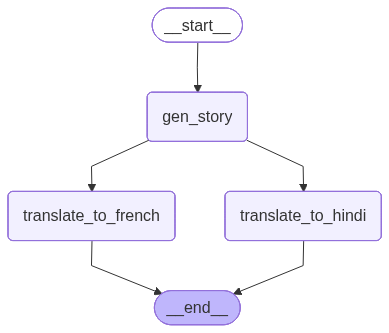

In [47]:
# State
class RouterState(TypedDict):
    user_input: Annotated[str, add_messages]
    story: Annotated[str, add_messages]
    hindi: Annotated[str, add_messages]
    french: Annotated[str, add_messages]

# Nodes
def gen_story(state: RouterState) -> RouterState:
    story  = gemini_llm.invoke(f"Write concise story on provided user input of 150-200 words. User Input: {state['user_input']}").content
    return {**state, "story": story}

def translate_to_hindi(state: RouterState) -> RouterState:
    return {**state, "hindi": gemini_llm.invoke(f"Translate following story to hindi. Story: {state['story']}").content}

def translate_to_french(state: RouterState) -> RouterState:
    return {**state, "french": gemini_llm.invoke(f"Translate following story to french. Story: {state['story']}").content}


# Graph
builder = StateGraph(RouterState)

#add nodes
builder.add_node("gen_story", gen_story)
builder.add_node("translate_to_hindi", translate_to_hindi)
builder.add_node("translate_to_french", translate_to_french)

# add edges
builder.add_edge(START, "gen_story")
builder.add_edge("gen_story", "translate_to_hindi")
builder.add_edge("gen_story", "translate_to_french")

builder.add_edge("translate_to_hindi", END)
builder.add_edge("translate_to_french", END)

graph = builder.compile()

display(Image(graph.get_graph().draw_mermaid_png()))

## Reflection Design Pattern

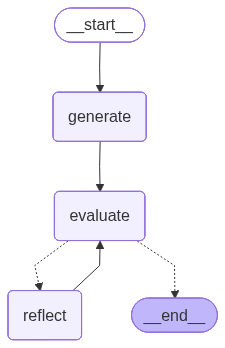

In [ ]:
# ---- State ----
class State(TypedDict):
    topic: str
    story: str
    feedback: str
    score: int


# ---- Prompts ----
generator_prompt = ChatPromptTemplate.from_template(
    """
You are a creative writer. Write a short, interesting story (max 150 words) about: {topic}
"""
)

evaluator_prompt = ChatPromptTemplate.from_template(
    """
You are an evaluator. Review the story below and return JSON:
{{
  "feedback": "short critique",
  "score": <integer 0-10>
}}
Story:
{story}
"""
)


# ---- Nodes ----
def generate(state: State):
    story = gemini_llm.invoke(generator_prompt.format(topic=state["topic"]))
    return {"story": story.content}


def evaluate(state: State):
    chain = evaluator_prompt | gemini_llm | JsonOutputParser()
    result = chain.invoke({"story": state["story"]})
    return {"feedback": result["feedback"], "score": result["score"]}


def reflect(state: State):
    if state["score"] < 8:
        revised_prompt = ChatPromptTemplate.from_template(
            """
        The evaluator said: {feedback}
        Improve the story below accordingly but keep it concise.
        Story:
        {story}
        """
        )
        improved = gemini_llm.invoke(revised_prompt.format(**state))
        return {"story": improved.content}
    return {"story": state["story"]}


# ---- Conditional routing function ----
def decide_next(state: State):
    return "reflect" if state["score"] < 8 else END


# ---- Graph ----
builder = StateGraph(State)
builder.add_node("generate", generate)
builder.add_node("evaluate", evaluate)
builder.add_node("reflect", reflect)

builder.add_edge(START, "generate")
builder.add_edge("generate", "evaluate")

# Explicit conditional routing for better visualization
builder.add_conditional_edges("evaluate", decide_next, {"reflect": "reflect"})

# Reflect loops back to evaluation
builder.add_edge("reflect", "evaluate")

memory = MemorySaver()
graph = builder.compile(checkpointer=memory)

display(Image(graph.get_graph().draw_mermaid_png()))

# ---- Run ----
# config = {"configurable": {"thread_id": "reflection_1"}}
# result = graph.invoke({"topic": "a robot learning to paint"}, config=config)
# print("🧠 Feedback:", result["feedback"])
# print("⭐ Final Score:", result["score"])
# print("\n📖 Final Story:\n", result["story"])

## Router Pattern

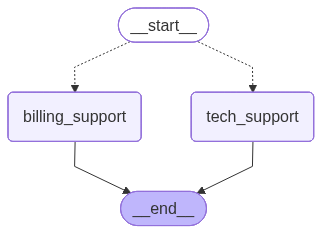

{'user_input': 'I want to know the price', 'response': 'I can help with billing issues!'}


In [52]:
# ---- State ----
class State(TypedDict):
    user_input: str
    response: str

# ---- Nodes ----
def tech_support(state: State):
    return {"response": "I can help with technical issues!"}

def billing_support(state: State):
    return {"response": "I can help with billing issues!"}

# ---- Router condition function ----
def route_condition(state: State):
    if "price" in state["user_input"].lower():
        return "billing_support"
    return "tech_support"

# ---- Build Graph ----
builder = StateGraph(State)
builder.add_node("tech_support", tech_support)
builder.add_node("billing_support", billing_support)

builder.add_conditional_edges(START, route_condition, {
    "tech_support": "tech_support",
    "billing_support": "billing_support"
})

builder.add_edge("tech_support", END)
builder.add_edge("billing_support", END)

graph = builder.compile()

display(Image(graph.get_graph().draw_mermaid_png()))
print(graph.invoke({"user_input": "I want to know the price"}))

## Sequential Pattern

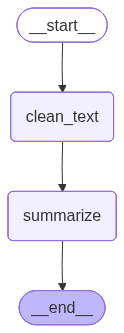

{'text': '  Hello World! This is LangGraph demo.  ', 'processed': 'hello world! this is langgraph demo.', 'summary': 'Summary: hello world! this is langgraph demo....'}


In [53]:
class State(TypedDict):
    text: str
    processed: str
    summary: str

def clean_text(state: State):
    return {"processed": state["text"].strip().lower()}

def summarize(state: State):
    return {"summary": f"Summary: {state['processed'][:50]}..."}

builder = StateGraph(State)
builder.add_node("clean_text", clean_text)
builder.add_node("summarize", summarize)

builder.add_edge(START, "clean_text")
builder.add_edge("clean_text", "summarize")
builder.add_edge("summarize", END)

graph = builder.compile()
display(Image(graph.get_graph().draw_mermaid_png()))
print(graph.invoke({"text": "  Hello World! This is LangGraph demo.  "}))

# Orchestrator Design Pattern

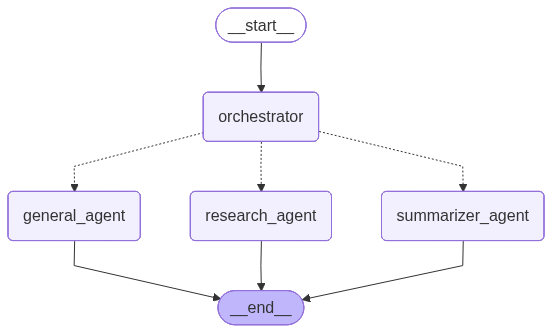


🧭 Query: Do research on renewable energy sources.
✅ Output: Research on renewable energy sources focuses on developing and optimizing technologies that harness naturally replenishing resources like solar, wind, hydro, geothermal, and biomass. Key areas include improving energy conversion efficiency, reducing costs, enhancing energy storage solutions (e.g., batteries, hydrogen), and developing smarter grid integration systems. Scientists are also exploring novel materials, advanced manufacturing techniques, and ways to overcome intermittency challenges. The ultimate goal is to accelerate the transition to a sustainable, low-carbon energy system, mitigate climate change, and enhance global energy security.

🧭 Query: Summarize the following text about machine learning.
✅ Output: Please provide the text you would like me to summarize about machine learning. I need the content to create the 3 concise sentences.

🧭 Query: Who is the CEO of Google?
✅ Output: Sundar Pichai


In [68]:
# --- Define State ---
class State(TypedDict):
    user_input: str
    output: str


# --- Agents ---
def research_agent(state: State):
    topic = state["user_input"]
    prompt = ChatPromptTemplate.from_template(
        "Provide a brief factual research summary (under 100 words) about: {topic}"
    )
    result = gemini_llm.invoke(prompt.format(topic=topic))
    return {"output": result.content}


def summarizer_agent(state: State):
    text = state["user_input"]
    prompt = ChatPromptTemplate.from_template(
        "Summarize the following text in 3 concise sentences:\n{text}"
    )
    result = gemini_llm.invoke(prompt.format(text=text))
    return {"output": result.content}


def general_agent(state: State):
    question = state["user_input"]
    prompt = ChatPromptTemplate.from_template(
        "Answer the following general question briefly:\n{question}"
    )
    result = gemini_llm.invoke(prompt.format(question=question))
    return {"output": result.content}


# --- Orchestrator (Router) ---
def orchestrator(state: State):
    text = state["user_input"].lower()
    if "research" in text or "study" in text:
        return "research_agent"
    elif "summarize" in text or "summary" in text:
        return "summarizer_agent"
    else:
        return "general_agent"


# --- Build Graph ---
builder = StateGraph(State)

builder.add_node("research_agent", research_agent)
builder.add_node("summarizer_agent", summarizer_agent)
builder.add_node("general_agent", general_agent)
builder.add_node("orchestrator", lambda s: {})  # placeholder node for visualization

builder.add_edge(START, "orchestrator")

builder.add_conditional_edges(
    "orchestrator",
    orchestrator,
    {
        "research_agent": "research_agent",
        "summarizer_agent": "summarizer_agent",
        "general_agent": "general_agent",
    },
)

builder.add_edge("research_agent", END)
builder.add_edge("summarizer_agent", END)
builder.add_edge("general_agent", END)

# --- Compile & Visualize ---
memory = MemorySaver()
graph = builder.compile(checkpointer=memory)
display(Image(graph.get_graph().draw_mermaid_png()))

# --- Run Example ---
queries = [
    "Do research on renewable energy sources.",
    "Summarize the following text about machine learning.",
    "Who is the CEO of Google?",
]

config = {"configurable": {"thread_id": "chat_1"}}

for q in queries:
    result = graph.invoke({"user_input": q}, config=config)
    print(f"\n🧭 Query: {q}")
    print("✅ Output:", result["output"])